## Dataset

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\nepta\OneDrive\Escritorio\world-cup-predictor


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import load_and_cache_results
from src.cleaning import clean_results, split_played_and_future_matches
from src.model import build_model_dataset, MODEL_FEATURES

from src.config import (
    CALIBRATOR_OOF_FOLDS,
    CALIBRATOR_MIN_TRAIN_RATIO,
)

In [3]:
raw_df = load_and_cache_results()

clean_df = clean_results(raw_df)

played_matches, future_matches = split_played_and_future_matches(clean_df)

model_df = build_model_dataset(played_matches)

df_exp = model_df.copy()

print("df_exp shape:", df_exp.shape)
df_exp.head()

Loading latest results from GitHub...
Saving latest results to: C:\Users\nepta\OneDrive\Escritorio\world-cup-predictor\data\raw\results.csv
df_exp shape: (15845, 47)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_id,...,diff_attack_10,diff_defense_10,diff_points_10,abs_diff_attack_5,abs_diff_defense_5,abs_diff_points_5,abs_diff_attack_10,abs_diff_defense_10,abs_diff_points_10,actual_result
0,2010-01-02,Yemen,Tajikistan,0,1,Friendly,Sana'a,Yemen,0,33588,...,-0.5,0.8,-0.4,0.2,0.8,0.8,0.5,0.8,0.4,A
1,2010-01-02,Syria,Zimbabwe,6,0,Friendly,Kuala Lumpur,Malaysia,1,33589,...,-0.1,-0.8,0.5,0.8,0.2,0.6,0.1,0.8,0.5,H
2,2010-01-02,Iran,North Korea,1,0,Friendly,Doha,Qatar,1,33590,...,-0.8,0.7,-0.4,1.2,0.6,1.2,0.8,0.7,0.4,H
3,2010-01-02,Qatar,Mali,0,0,Friendly,Doha,Qatar,0,33591,...,-0.5,0.5,-0.8,0.2,0.4,0.2,0.5,0.5,0.8,D
4,2010-01-03,Angola,Gambia,1,1,Friendly,Vila Real de Santo António,Portugal,1,33592,...,-0.3,0.2,-0.5,0.8,0.4,1.0,0.3,0.2,0.5,D


In [4]:
print(df_exp.columns.tolist())

['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'match_id', 'home_elo_before', 'away_elo_before', 'elo_diff', 'elo_tanh_400', 'abs_elo_tanh_400', 'abs_elo_diff', 'is_friendly', 'is_world_cup', 'is_world_cup_qualifier', 'is_continental_cup', 'is_nations_league', 'is_competitive', 'home_avg_goals_for_5', 'home_avg_goals_against_5', 'home_avg_points_5', 'home_avg_goals_for_10', 'home_avg_goals_against_10', 'home_avg_points_10', 'away_avg_goals_for_5', 'away_avg_goals_against_5', 'away_avg_points_5', 'away_avg_goals_for_10', 'away_avg_goals_against_10', 'away_avg_points_10', 'diff_attack_5', 'diff_defense_5', 'diff_points_5', 'diff_attack_10', 'diff_defense_10', 'diff_points_10', 'abs_diff_attack_5', 'abs_diff_defense_5', 'abs_diff_points_5', 'abs_diff_attack_10', 'abs_diff_defense_10', 'abs_diff_points_10', 'actual_result']


In [5]:
required_cols = [
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "actual_result",
    *MODEL_FEATURES,
]

missing_cols = [col for col in required_cols if col not in df_exp.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")

All required columns are available.


In [6]:
class_dist = (
    df_exp["actual_result"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
    .rename(columns={"index": "actual_result"})
)

class_dist

,actual_result,proportion
0,H,0.478511
1,A,0.289303
2,D,0.232187


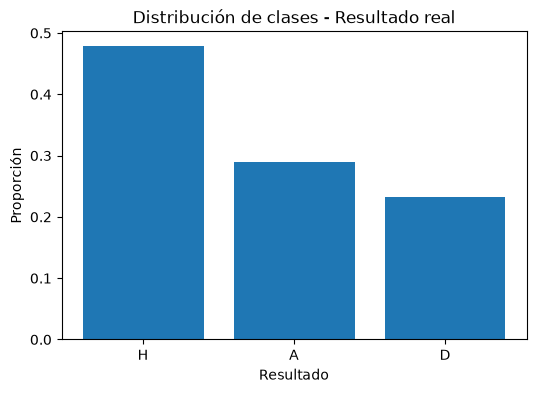

In [7]:
plt.figure(figsize=(6, 4))
plt.bar(class_dist["actual_result"], class_dist["proportion"])
plt.title("Distribución de clases - Resultado real")
plt.xlabel("Resultado")
plt.ylabel("Proporción")
plt.show()

In [8]:
print(df_exp.shape)

(15845, 47)


In [9]:
df_exp.info()

<class 'pandas.DataFrame'>
RangeIndex: 15845 entries, 0 to 15844
Data columns (total 47 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       15845 non-null  datetime64[us]
 1   home_team                  15845 non-null  str           
 2   away_team                  15845 non-null  str           
 3   home_score                 15845 non-null  int64         
 4   away_score                 15845 non-null  int64         
 5   tournament                 15845 non-null  str           
 6   city                       15845 non-null  str           
 7   country                    15845 non-null  str           
 8   neutral                    15845 non-null  int64         
 9   match_id                   15845 non-null  int64         
 10  home_elo_before            15845 non-null  float64       
 11  away_elo_before            15845 non-null  float64       
 12  elo_diff       

In [10]:
df_exp["actual_result"].value_counts(normalize=True)

actual_result
H    0.478511
A    0.289303
D    0.232187
Name: proportion, dtype: float64

In [11]:
print(f"Número de features: {len(MODEL_FEATURES)}")
print(MODEL_FEATURES)

Número de features: 26
['home_avg_goals_for_5', 'home_avg_goals_against_5', 'home_avg_points_5', 'home_avg_goals_for_10', 'home_avg_goals_against_10', 'home_avg_points_10', 'away_avg_goals_for_5', 'away_avg_goals_against_5', 'away_avg_points_5', 'away_avg_goals_for_10', 'away_avg_goals_against_10', 'away_avg_points_10', 'diff_attack_5', 'diff_defense_5', 'diff_points_5', 'diff_attack_10', 'diff_defense_10', 'diff_points_10', 'neutral', 'elo_tanh_400', 'is_friendly', 'is_world_cup', 'is_world_cup_qualifier', 'is_continental_cup', 'is_nations_league', 'is_competitive']


## Splits

In [12]:
df_exp = df_exp.sort_values("date").reset_index(drop=True)

split_date = "2023-01-01"

train_df = df_exp[df_exp["date"] < split_date].copy()
test_df = df_exp[df_exp["date"] >= split_date].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train dates:", train_df["date"].min(), "→", train_df["date"].max())
print("Test dates:", test_df["date"].min(), "→", test_df["date"].max())

Train shape: (12219, 47)
Test shape: (3626, 47)
Train dates: 2010-01-02 00:00:00 → 2022-12-30 00:00:00
Test dates: 2023-01-02 00:00:00 → 2026-06-18 00:00:00


In [13]:
train_dist = train_df["actual_result"].value_counts(normalize=True)
test_dist = test_df["actual_result"].value_counts(normalize=True)

print("Train class distribution:")
print(train_dist)

print("\nTest class distribution:")
print(test_dist)

Train class distribution:
actual_result
H    0.480154
A    0.287258
D    0.232589
Name: proportion, dtype: float64

Test class distribution:
actual_result
H    0.472973
A    0.296194
D    0.230833
Name: proportion, dtype: float64


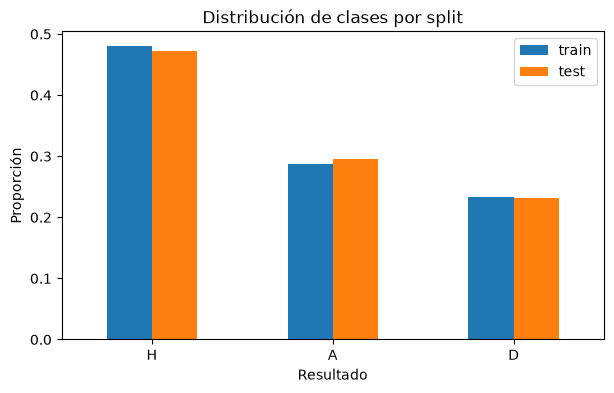

In [14]:
dist_df = pd.DataFrame({
    "train": train_dist,
    "test": test_dist
}).fillna(0)

dist_df.plot(kind="bar", figsize=(7, 4))

plt.title("Distribución de clases por split")
plt.xlabel("Resultado")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

## Experiment 1 - Poisson + calibrador multinominal actual

In [15]:
from src.evaluation import evaluate_model_temporal_split
from src.probabilities import (
    RAW_PROB_COLS,
    BLENDED_PROB_COLS,
    CALIBRATED_PROB_COLS,
)

In [16]:
exp1_results = evaluate_model_temporal_split(
    model_df=df_exp,
    train_calibrator=True,
    n_oof_folds=CALIBRATOR_OOF_FOLDS,
    min_train_ratio=CALIBRATOR_MIN_TRAIN_RATIO,
)

### Metrics

In [17]:
exp1_train_metrics = exp1_results["train_result_metrics"]
exp1_test_metrics = exp1_results["test_result_metrics"]

exp1_test_metrics

{'raw': {'accuracy': 0.604522890237176,
  'log_loss': np.float64(0.8669818297080878),
  'draw_real_rate': np.float64(0.23083287369001654),
  'draw_pred_rate': np.float64(0.0)},
 'blended': {'accuracy': 0.6003861003861004,
  'log_loss': np.float64(0.8933657695696725),
  'draw_real_rate': np.float64(0.23083287369001654),
  'draw_pred_rate': np.float64(0.0)},
 'oof_multinomial_calibrator': {'accuracy': 0.6047986762272477,
  'log_loss': np.float64(0.8632988514749312),
  'draw_real_rate': np.float64(0.23083287369001654),
  'draw_pred_rate': np.float64(0.022614451185879757)}}

In [18]:
for model_name, metrics in exp1_test_metrics.items():
    print(model_name)
    print(f"Accuracy:       {metrics['accuracy']:.4f}")
    print(f"Log loss:       {metrics['log_loss']:.4f}")
    print(f"Draw real rate: {metrics['draw_real_rate']:.4f}")
    print(f"Draw pred rate: {metrics['draw_pred_rate']:.4f}")
    print()

raw
Accuracy:       0.6045
Log loss:       0.8670
Draw real rate: 0.2308
Draw pred rate: 0.0000

blended
Accuracy:       0.6004
Log loss:       0.8934
Draw real rate: 0.2308
Draw pred rate: 0.0000

oof_multinomial_calibrator
Accuracy:       0.6048
Log loss:       0.8633
Draw real rate: 0.2308
Draw pred rate: 0.0226



In [19]:
exp1_train_predictions = exp1_results["train_predictions"].copy()
exp1_test_predictions = exp1_results["test_predictions"].copy()

### Summary - Experiment 1 - Baseline

In [20]:
exp_summary = []

for model_name, metrics in exp1_test_metrics.items():
    exp_summary.append({
        "experiment": "Exp 1 - Baseline",
        "model": model_name,
        "accuracy": metrics["accuracy"],
        "log_loss": metrics["log_loss"],
        "draw_real_rate": metrics["draw_real_rate"],
        "draw_pred_rate": metrics["draw_pred_rate"],
    })

summary_df = pd.DataFrame(exp_summary)
summary_df

,experiment,model,accuracy,log_loss,draw_real_rate,draw_pred_rate
0,Exp 1 - Baseline,raw,0.604523,0.866982,0.230833,0.000000
1,Exp 1 - Baseline,blended,0.600386,0.893366,0.230833,0.000000
2,Exp 1 - Baseline,oof_multinomial_calibrator,0.604799,0.863299,0.230833,0.022614


#### Distribución de probabilidades calibradas.

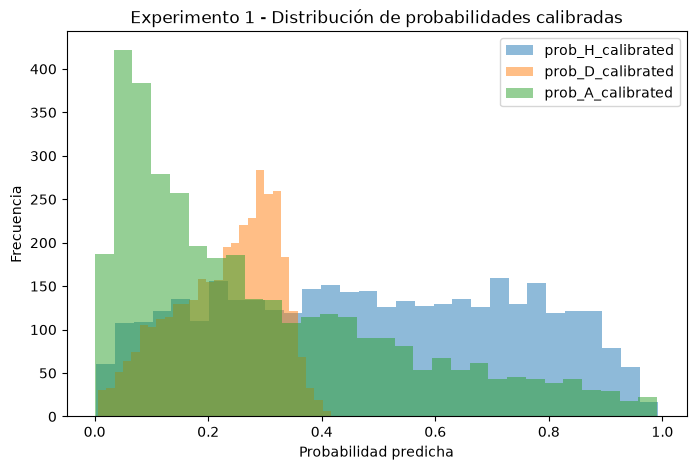

In [21]:
proba_cols_exp1 = CALIBRATED_PROB_COLS

test_probas_long = exp1_test_predictions[proba_cols_exp1].melt(
    var_name="class",
    value_name="predicted_probability"
)

plt.figure(figsize=(8, 5))

for class_name in test_probas_long["class"].unique():
    subset = test_probas_long[test_probas_long["class"] == class_name]
    plt.hist(
        subset["predicted_probability"],
        bins=30,
        alpha=0.5,
        label=class_name,
    )

plt.title("Experimento 1 - Distribución de probabilidades calibradas")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

#### Matriz de confusión

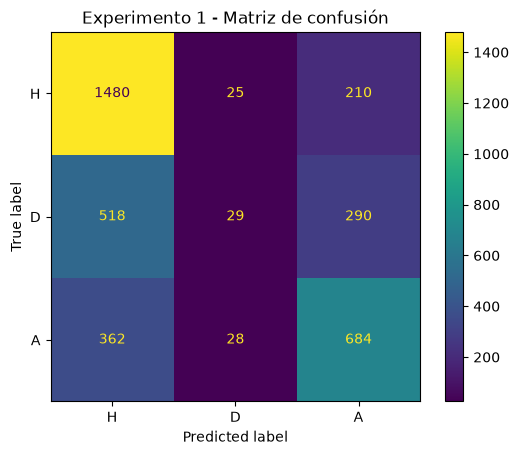

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels = ["H", "D", "A"]

cm = confusion_matrix(
    exp1_test_predictions["actual_result"],
    exp1_test_predictions["predicted_result_calibrated"],
    labels=labels,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

disp.plot(values_format="d")
plt.title("Experimento 1 - Matriz de confusión")
plt.show()

#### Log Loss por clases

In [23]:
print("Columnas calibradas esperadas:")
print(CALIBRATED_PROB_COLS)

print("\nColumnas disponibles con 'calibrated':")
[col for col in exp1_test_predictions.columns if "calibrated" in col]

print("\nModelos disponibles en exp1_test_metrics:")
print(exp1_test_metrics.keys())

Columnas calibradas esperadas:
['prob_H_calibrated', 'prob_D_calibrated', 'prob_A_calibrated']

Columnas disponibles con 'calibrated':

Modelos disponibles en exp1_test_metrics:
dict_keys(['raw', 'blended', 'oof_multinomial_calibrator'])


In [24]:
from sklearn.metrics import log_loss

class_log_losses = []

for label in labels:
    y_true_binary = (exp1_test_predictions["actual_result"] == label).astype(int)

    if label == "H":
        proba_col = "prob_H_calibrated"
    elif label == "D":
        proba_col = "prob_D_calibrated"
    else:
        proba_col = "prob_A_calibrated"

    ll = log_loss(
        y_true_binary,
        exp1_test_predictions[proba_col],
        labels=[0, 1],
    )

    class_log_losses.append({
        "class": label,
        "log_loss": ll,
    })

class_log_loss_df = pd.DataFrame(class_log_losses)
class_log_loss_df

,class,log_loss
0,H,0.541939
1,D,0.518860
2,A,0.466034


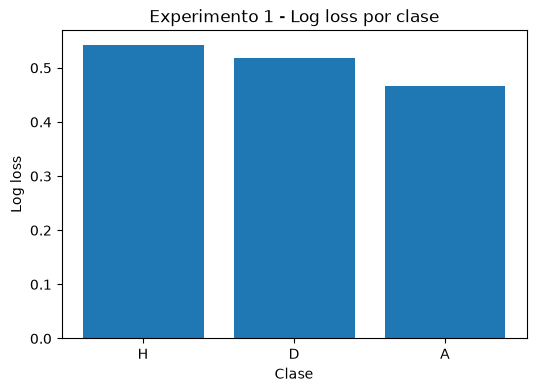

In [25]:
plt.figure(figsize=(6, 4))
plt.bar(class_log_loss_df["class"], class_log_loss_df["log_loss"])

plt.title("Experimento 1 - Log loss por clase")
plt.xlabel("Clase")
plt.ylabel("Log loss")
plt.show()

#### Empates por clases

In [26]:
list(exp1_test_metrics.keys())

['raw', 'blended', 'oof_multinomial_calibrator']

In [27]:
calibrated_model_name = list(exp1_test_metrics.keys())[-1]
calibrated_model_name

'oof_multinomial_calibrator'

In [28]:
draw_comparison = pd.DataFrame({
    "metric": ["Draw real rate", "Draw predicted rate"],
    "value": [
        exp1_test_metrics[calibrated_model_name]["draw_real_rate"],
        exp1_test_metrics[calibrated_model_name]["draw_pred_rate"],
    ],
})

draw_comparison

,metric,value
0,Draw real rate,0.230833
1,Draw predicted rate,0.022614


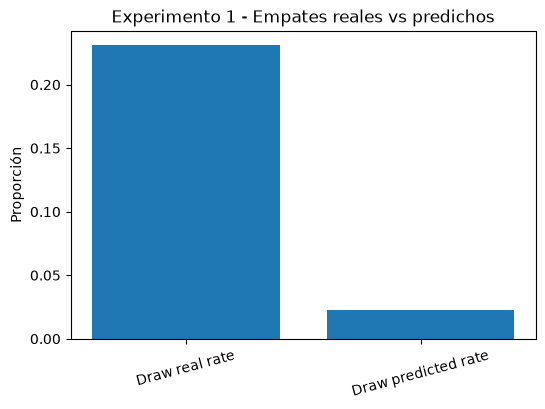

In [29]:
plt.figure(figsize=(6, 4))
plt.bar(draw_comparison["metric"], draw_comparison["value"])

plt.title("Experimento 1 - Empates reales vs predichos")
plt.ylabel("Proporción")
plt.xticks(rotation=15)
plt.show()

## Experiment 2 -  Poisson + calibrador multinominal con balanceador de clases

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

In [31]:
print("RAW_PROB_COLS:", RAW_PROB_COLS)
print("CALIBRATED_PROB_COLS:", CALIBRATED_PROB_COLS)
print("Columnas con raw:")
print([col for col in exp1_train_predictions.columns if "raw" in col or "prob" in col])

RAW_PROB_COLS: ['prob_home_win', 'prob_draw', 'prob_away_win']
CALIBRATED_PROB_COLS: ['prob_H_calibrated', 'prob_D_calibrated', 'prob_A_calibrated']
Columnas con raw:
['prob_home_win', 'prob_draw', 'prob_away_win', 'prob_home_win_blended', 'prob_draw_blended', 'prob_away_win_blended', 'prob_H_calibrated', 'prob_D_calibrated', 'prob_A_calibrated']


In [32]:
calibrator_input_cols = RAW_PROB_COLS

X_cal_train = exp1_train_predictions[calibrator_input_cols].copy()
y_cal_train = exp1_train_predictions["actual_result"].copy()

X_cal_test = exp1_test_predictions[calibrator_input_cols].copy()
y_cal_test = exp1_test_predictions["actual_result"].copy()

In [33]:
balanced_calibrator = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)

balanced_calibrator.fit(X_cal_train, y_cal_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [34]:
balanced_classes = list(balanced_calibrator.classes_)
balanced_classes

['A', 'D', 'H']

In [35]:
balanced_test_proba = balanced_calibrator.predict_proba(X_cal_test)
balanced_test_pred = balanced_calibrator.predict(X_cal_test)

### Metrics

In [36]:
exp2_accuracy = accuracy_score(y_cal_test, balanced_test_pred)

exp2_log_loss = log_loss(
    y_cal_test,
    balanced_test_proba,
    labels=balanced_classes,
)

exp2_draw_real_rate = (y_cal_test == "D").mean()
exp2_draw_pred_rate = (balanced_test_pred == "D").mean()

exp2_metrics = {
    "accuracy": exp2_accuracy,
    "log_loss": exp2_log_loss,
    "draw_real_rate": exp2_draw_real_rate,
    "draw_pred_rate": exp2_draw_pred_rate,
}

exp2_metrics

{'accuracy': 0.5642581356867071,
 'log_loss': 0.8996758484006048,
 'draw_real_rate': np.float64(0.23083287369001654),
 'draw_pred_rate': np.float64(0.26475455046883617)}

### Summary 

In [37]:
summary_df = pd.concat([
    summary_df,
    pd.DataFrame([{
        "experiment": "Exp 2 - Balanced class weight",
        "model": "poisson_multinomial_balanced_calibrator",
        "accuracy": exp2_metrics["accuracy"],
        "log_loss": exp2_metrics["log_loss"],
        "draw_real_rate": exp2_metrics["draw_real_rate"],
        "draw_pred_rate": exp2_metrics["draw_pred_rate"],
    }])
], ignore_index=True)

summary_df

,experiment,model,accuracy,log_loss,draw_real_rate,draw_pred_rate
0,Exp 1 - Baseline,raw,0.604523,0.866982,0.230833,0.000000
1,Exp 1 - Baseline,blended,0.600386,0.893366,0.230833,0.000000
2,Exp 1 - Baseline,oof_multinomial_calibrator,0.604799,0.863299,0.230833,0.022614
3,Exp 2 - Balanced class weight,poisson_multinomial_balanced_calibrator,0.564258,0.899676,0.230833,0.264755


## Experiment 3 - Modelo baseline con features contextuales

### Features contextuales

In [38]:
exp3_train = exp1_train_predictions.copy()
exp3_test = exp1_test_predictions.copy()

for df in [exp3_train, exp3_test]:
    df["lambda_diff"] = df["lambda_home"] - df["lambda_away"]
    df["abs_lambda_diff"] = df["lambda_diff"].abs()
    df["total_lambda"] = df["lambda_home"] + df["lambda_away"]
    df["closed_match_flag"] = (df["abs_lambda_diff"] < 0.3).astype(int)

In [39]:
candidate_context_cols = [
    "lambda_home",
    "lambda_away",
    "lambda_diff",
    "abs_lambda_diff",
    "total_lambda",
    "closed_match_flag",
    "elo_diff",
    "elo_tanh_400",
    "neutral",
    "is_friendly",
    "is_world_cup",
    "is_world_cup_qualifier",
    "is_continental_cup",
    "is_nations_league",
    "is_competitive",
]

context_cols = [
    col for col in candidate_context_cols
    if col in exp3_train.columns
]

context_cols

['lambda_home',
 'lambda_away',
 'lambda_diff',
 'abs_lambda_diff',
 'total_lambda',
 'closed_match_flag',
 'elo_diff',
 'elo_tanh_400',
 'neutral',
 'is_friendly',
 'is_world_cup',
 'is_world_cup_qualifier',
 'is_continental_cup',
 'is_nations_league',
 'is_competitive']

In [40]:
exp3_calibrator_input_cols = RAW_PROB_COLS + context_cols

exp3_calibrator_input_cols

['prob_home_win',
 'prob_draw',
 'prob_away_win',
 'lambda_home',
 'lambda_away',
 'lambda_diff',
 'abs_lambda_diff',
 'total_lambda',
 'closed_match_flag',
 'elo_diff',
 'elo_tanh_400',
 'neutral',
 'is_friendly',
 'is_world_cup',
 'is_world_cup_qualifier',
 'is_continental_cup',
 'is_nations_league',
 'is_competitive']

In [41]:
X_exp3_train = exp3_train[exp3_calibrator_input_cols].copy()
y_exp3_train = exp3_train["actual_result"].copy()

X_exp3_test = exp3_test[exp3_calibrator_input_cols].copy()
y_exp3_test = exp3_test["actual_result"].copy()

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

contextual_calibrator = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42,
        )),
    ]
)

contextual_calibrator.fit(X_exp3_train, y_exp3_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['A','D','H']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['prob_home_win','prob_draw','prob_away_win',...,'is_continental_cup', 'is_nations_league','is_competitive']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [43]:
exp3_classes = list(contextual_calibrator.named_steps["model"].classes_)

exp3_test_proba = contextual_calibrator.predict_proba(X_exp3_test)
exp3_test_pred = contextual_calibrator.predict(X_exp3_test)

In [44]:
exp3_accuracy = accuracy_score(y_exp3_test, exp3_test_pred)

exp3_log_loss = log_loss(
    y_exp3_test,
    exp3_test_proba,
    labels=exp3_classes,
)

exp3_draw_real_rate = (y_exp3_test == "D").mean()
exp3_draw_pred_rate = (exp3_test_pred == "D").mean()

exp3_metrics = {
    "accuracy": exp3_accuracy,
    "log_loss": exp3_log_loss,
    "draw_real_rate": exp3_draw_real_rate,
    "draw_pred_rate": exp3_draw_pred_rate,
}

exp3_metrics

{'accuracy': 0.6036955322669608,
 'log_loss': 0.8609254147859821,
 'draw_real_rate': np.float64(0.23083287369001654),
 'draw_pred_rate': np.float64(0.001654715940430226)}

In [45]:
summary_df = pd.concat([
    summary_df,
    pd.DataFrame([{
        "experiment": "Exp 3 - Contextual calibrator",
        "model": "poisson_contextual_multinomial_calibrator",
        "accuracy": exp3_metrics["accuracy"],
        "log_loss": exp3_metrics["log_loss"],
        "draw_real_rate": exp3_metrics["draw_real_rate"],
        "draw_pred_rate": exp3_metrics["draw_pred_rate"],
    }])
], ignore_index=True)

summary_df

,experiment,model,accuracy,log_loss,draw_real_rate,draw_pred_rate
0,Exp 1 - Baseline,raw,0.604523,0.866982,0.230833,0.000000
1,Exp 1 - Baseline,blended,0.600386,0.893366,0.230833,0.000000
2,Exp 1 - Baseline,oof_multinomial_calibrator,0.604799,0.863299,0.230833,0.022614
3,Exp 2 - Balanced class weight,poisson_multinomial_balanced_calibrator,0.564258,0.899676,0.230833,0.264755
4,Exp 3 - Contextual calibrator,poisson_contextual_multinomial_calibrator,0.603696,0.860925,0.230833,0.001655


#### Experiment 3b

In [46]:
exp3b_input_cols = RAW_PROB_COLS + [
    "abs_lambda_diff",
    "total_lambda",
    "closed_match_flag",
]

In [47]:
X_exp3b_train = exp3_train[exp3b_input_cols].copy()
X_exp3b_test = exp3_test[exp3b_input_cols].copy()

contextual_calibrator_3b = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42,
        )),
    ]
)

contextual_calibrator_3b.fit(X_exp3b_train, y_exp3_train)

exp3b_classes = list(contextual_calibrator_3b.named_steps["model"].classes_)
exp3b_test_proba = contextual_calibrator_3b.predict_proba(X_exp3b_test)
exp3b_test_pred = contextual_calibrator_3b.predict(X_exp3b_test)

exp3b_metrics = {
    "accuracy": accuracy_score(y_exp3_test, exp3b_test_pred),
    "log_loss": log_loss(
        y_exp3_test,
        exp3b_test_proba,
        labels=exp3b_classes,
    ),
    "draw_real_rate": (y_exp3_test == "D").mean(),
    "draw_pred_rate": (exp3b_test_pred == "D").mean(),
}

exp3b_metrics

{'accuracy': 0.6036955322669608,
 'log_loss': 0.8673551167985414,
 'draw_real_rate': np.float64(0.23083287369001654),
 'draw_pred_rate': np.float64(0.0002757859900717044)}

In [48]:
summary_df = pd.concat([
    summary_df,
    pd.DataFrame([{
        "experiment": "Exp 3B - Draw-focused contextual calibrator",
        "model": "poisson_draw_focused_contextual_calibrator",
        "accuracy": exp3b_metrics["accuracy"],
        "log_loss": exp3b_metrics["log_loss"],
        "draw_real_rate": exp3b_metrics["draw_real_rate"],
        "draw_pred_rate": exp3b_metrics["draw_pred_rate"],
    }])
], ignore_index=True)

summary_df

,experiment,model,accuracy,log_loss,draw_real_rate,draw_pred_rate
0,Exp 1 - Baseline,raw,0.604523,0.866982,0.230833,0.000000
1,Exp 1 - Baseline,blended,0.600386,0.893366,0.230833,0.000000
2,Exp 1 - Baseline,oof_multinomial_calibrator,0.604799,0.863299,0.230833,0.022614
3,Exp 2 - Balanced class weight,poisson_multinomial_balanced_calibrator,0.564258,0.899676,0.230833,0.264755
4,Exp 3 - Contextual calibrator,poisson_contextual_multinomial_calibrator,0.603696,0.860925,0.230833,0.001655
5,Exp 3B - Draw-focused contextual calibrator,poisson_draw_focused_contextual_calibrator,0.603696,0.867355,0.230833,0.000276


## Experiment 4 - Poisson bivariado

In [49]:
from scipy.special import gammaln, logsumexp
from sklearn.metrics import accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression

In [50]:
RESULT_LABELS = ["H", "D", "A"]

BIVAR_PROB_COLS = [
    "prob_home_bivar",
    "prob_draw_bivar",
    "prob_away_bivar",
]

In [51]:
def _log_component(n, lam):
    """
    Log of lam^n / n!, handling lam=0 safely.
    """
    if n == 0 and lam == 0:
        return 0.0
    
    if lam <= 0:
        return -np.inf
    
    return n * np.log(lam) - gammaln(n + 1)

In [59]:
from scipy.stats import poisson

RESULT_LABELS = ["H", "D", "A"]

BIVAR_PROB_COLS = [
    "prob_home_bivar",
    "prob_draw_bivar",
    "prob_away_bivar",
]


def fast_bivariate_result_probabilities(
    lambda_home,
    lambda_away,
    common_factor=0.05,
    max_goals=10,
    eps=1e-10,
):
    """
    Fast approximation/equivalent for H-D-A probabilities under the bivariate
    Poisson structure.

    The shared component affects both teams equally, so for result probabilities
    we can work with the independent components:
    home = home_independent + common
    away = away_independent + common
    """
    lambda_common = common_factor * min(lambda_home, lambda_away)

    lambda_home_ind = max(lambda_home - lambda_common, eps)
    lambda_away_ind = max(lambda_away - lambda_common, eps)

    goals = np.arange(max_goals + 1)

    home_pmf = poisson.pmf(goals, lambda_home_ind)
    away_pmf = poisson.pmf(goals, lambda_away_ind)

    score_matrix = np.outer(home_pmf, away_pmf)
    score_matrix = score_matrix / score_matrix.sum()

    prob_home = np.tril(score_matrix, k=-1).sum()
    prob_draw = np.trace(score_matrix)
    prob_away = np.triu(score_matrix, k=1).sum()

    return prob_home, prob_draw, prob_away


def add_bivariate_probabilities(
    df,
    common_factor=0.05,
    max_goals=10,
):
    """
    Adds fast bivariate Poisson result probabilities.
    """
    df_out = df.copy()

    probabilities = np.array([
        fast_bivariate_result_probabilities(
            lambda_home=row.lambda_home,
            lambda_away=row.lambda_away,
            common_factor=common_factor,
            max_goals=max_goals,
        )
        for row in df_out.itertuples(index=False)
    ])

    df_out[BIVAR_PROB_COLS] = probabilities

    pred_idx = probabilities.argmax(axis=1)

    df_out["predicted_result_bivar"] = [
        RESULT_LABELS[i] for i in pred_idx
    ]

    df_out["confidence_bivar"] = probabilities.max(axis=1)

    return df_out

In [60]:
common_factor_grid = [
    0.00,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
]

In [61]:
bivar_tuning_results = []

for common_factor in common_factor_grid:
    print(f"Testing common_factor={common_factor}")

    val_bivar = add_bivariate_probabilities(
        exp4_inner_val,
        common_factor=common_factor,
        max_goals=10,
    )

    y_val = val_bivar["actual_result"]

    val_accuracy = accuracy_score(
        y_val,
        val_bivar["predicted_result_bivar"],
    )

    val_log_loss = log_loss(
        y_val,
        val_bivar[BIVAR_PROB_COLS],
        labels=RESULT_LABELS,
    )

    val_draw_real_rate = (y_val == "D").mean()
    val_draw_pred_rate = (val_bivar["predicted_result_bivar"] == "D").mean()

    bivar_tuning_results.append({
        "common_factor": common_factor,
        "accuracy": val_accuracy,
        "log_loss": val_log_loss,
        "draw_real_rate": val_draw_real_rate,
        "draw_pred_rate": val_draw_pred_rate,
    })

bivar_tuning_df = pd.DataFrame(bivar_tuning_results)
bivar_tuning_df

Testing common_factor=0.0


c:\Users\nepta\OneDrive\Escritorio\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['H', 'D', 'A']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['A', 'D', 'H'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


Testing common_factor=0.05


c:\Users\nepta\OneDrive\Escritorio\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['H', 'D', 'A']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['A', 'D', 'H'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


Testing common_factor=0.1


c:\Users\nepta\OneDrive\Escritorio\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['H', 'D', 'A']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['A', 'D', 'H'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


Testing common_factor=0.15


c:\Users\nepta\OneDrive\Escritorio\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['H', 'D', 'A']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['A', 'D', 'H'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


Testing common_factor=0.2


c:\Users\nepta\OneDrive\Escritorio\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['H', 'D', 'A']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['A', 'D', 'H'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


Testing common_factor=0.25


c:\Users\nepta\OneDrive\Escritorio\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['H', 'D', 'A']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['A', 'D', 'H'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


Testing common_factor=0.3


c:\Users\nepta\OneDrive\Escritorio\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['H', 'D', 'A']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['A', 'D', 'H'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


,common_factor,accuracy,log_loss,draw_real_rate,draw_pred_rate
0,0.00,0.608838,1.778270,0.231588,0.000000
1,0.05,0.608838,1.793960,0.231588,0.000000
2,0.10,0.608838,1.810881,0.231588,0.000000
3,0.15,0.608429,1.829204,0.231588,0.000409
4,0.20,0.608020,1.849132,0.231588,0.005728
5,0.25,0.607610,1.870915,0.231588,0.021277
6,0.30,0.607610,1.894858,0.231588,0.049509


In [62]:
exp4_train_base = exp1_train_predictions.copy().sort_values("date").reset_index(drop=True)
exp4_test_base = exp1_test_predictions.copy().sort_values("date").reset_index(drop=True)

In [63]:
cut_idx = int(len(exp4_train_base) * 0.8)

exp4_inner_train = exp4_train_base.iloc[:cut_idx].copy()
exp4_inner_val = exp4_train_base.iloc[cut_idx:].copy()

print("Inner train:", exp4_inner_train.shape)
print("Inner val:", exp4_inner_val.shape)
print("Inner val dates:", exp4_inner_val["date"].min(), "→", exp4_inner_val["date"].max())

Inner train: (9775, 62)
Inner val: (2444, 62)
Inner val dates: 2019-12-05 00:00:00 → 2022-12-30 00:00:00


In [66]:
best_bivar_row = bivar_tuning_df.sort_values("log_loss").iloc[0]

best_common_factor = best_bivar_row["common_factor"]

best_bivar_row

common_factor     0.000000
accuracy          0.608838
log_loss          1.778270
draw_real_rate    0.231588
draw_pred_rate    0.000000
Name: 0, dtype: float64

In [67]:
print(f"Best common_factor: {best_common_factor}")

Best common_factor: 0.0


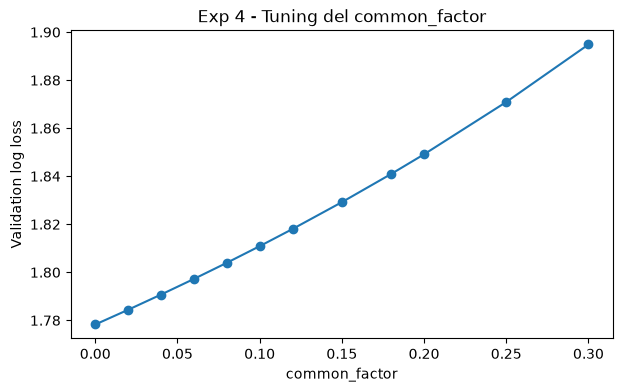

In [68]:
plt.figure(figsize=(7, 4))

plt.plot(
    bivar_tuning_df["common_factor"],
    bivar_tuning_df["log_loss"],
    marker="o",
)

plt.title("Exp 4 - Tuning del common_factor")
plt.xlabel("common_factor")
plt.ylabel("Validation log loss")
plt.show()

In [69]:
exp4_train_bivar = add_bivariate_probabilities(
    exp4_train_base,
    common_factor=best_common_factor,
    max_goals=10,
)

exp4_test_bivar = add_bivariate_probabilities(
    exp4_test_base,
    common_factor=best_common_factor,
    max_goals=10,
)

In [70]:
y_exp4_test = exp4_test_bivar["actual_result"]

exp4a_metrics = {
    "accuracy": accuracy_score(
        y_exp4_test,
        exp4_test_bivar["predicted_result_bivar"],
    ),
    "log_loss": log_loss(
        y_exp4_test,
        exp4_test_bivar[BIVAR_PROB_COLS],
        labels=RESULT_LABELS,
    ),
    "draw_real_rate": (y_exp4_test == "D").mean(),
    "draw_pred_rate": (exp4_test_bivar["predicted_result_bivar"] == "D").mean(),
}

exp4a_metrics

c:\Users\nepta\OneDrive\Escritorio\world-cup-predictor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['H', 'D', 'A']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['A', 'D', 'H'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


{'accuracy': 0.604522890237176,
 'log_loss': 1.8046821173740302,
 'draw_real_rate': np.float64(0.23083287369001654),
 'draw_pred_rate': np.float64(0.0)}

In [71]:
summary_df = pd.concat([
    summary_df,
    pd.DataFrame([{
        "experiment": "Exp 4A - Bivariate Poisson",
        "model": f"bivariate_poisson_common_factor_{best_common_factor}",
        "accuracy": exp4a_metrics["accuracy"],
        "log_loss": exp4a_metrics["log_loss"],
        "draw_real_rate": exp4a_metrics["draw_real_rate"],
        "draw_pred_rate": exp4a_metrics["draw_pred_rate"],
    }])
], ignore_index=True)

summary_df

,experiment,model,accuracy,log_loss,draw_real_rate,draw_pred_rate
0,Exp 1 - Baseline,raw,0.604523,0.866982,0.230833,0.000000
1,Exp 1 - Baseline,blended,0.600386,0.893366,0.230833,0.000000
2,Exp 1 - Baseline,oof_multinomial_calibrator,0.604799,0.863299,0.230833,0.022614
3,Exp 2 - Balanced class weight,poisson_multinomial_balanced_calibrator,0.564258,0.899676,0.230833,0.264755
4,Exp 3 - Contextual calibrator,poisson_contextual_multinomial_calibrator,0.603696,0.860925,0.230833,0.001655
5,Exp 3B - Draw-focused contextual calibrator,poisson_draw_focused_contextual_calibrator,0.603696,0.867355,0.230833,0.000276
6,Exp 4A - Bivariate Poisson,bivariate_poisson_common_factor_0.0,0.604523,1.804682,0.230833,0.000000


## Conclusiones generales de los experimentos

In [73]:
final_summary_df = summary_df.copy()

final_summary_df = final_summary_df.sort_values(
    by="log_loss",
    ascending=True
).reset_index(drop=True)

final_summary_df

,experiment,model,accuracy,log_loss,draw_real_rate,draw_pred_rate
0,Exp 3 - Contextual calibrator,poisson_contextual_multinomial_calibrator,0.603696,0.860925,0.230833,0.001655
1,Exp 1 - Baseline,oof_multinomial_calibrator,0.604799,0.863299,0.230833,0.022614
2,Exp 1 - Baseline,raw,0.604523,0.866982,0.230833,0.000000
3,Exp 3B - Draw-focused contextual calibrator,poisson_draw_focused_contextual_calibrator,0.603696,0.867355,0.230833,0.000276
4,Exp 1 - Baseline,blended,0.600386,0.893366,0.230833,0.000000
5,Exp 2 - Balanced class weight,poisson_multinomial_balanced_calibrator,0.564258,0.899676,0.230833,0.264755
6,Exp 4A - Bivariate Poisson,bivariate_poisson_common_factor_0.0,0.604523,1.804682,0.230833,0.000000


In [74]:
final_summary_df[[
    "experiment",
    "model",
    "accuracy",
    "log_loss",
    "draw_real_rate",
    "draw_pred_rate",
]]

,experiment,model,accuracy,log_loss,draw_real_rate,draw_pred_rate
0,Exp 3 - Contextual calibrator,poisson_contextual_multinomial_calibrator,0.603696,0.860925,0.230833,0.001655
1,Exp 1 - Baseline,oof_multinomial_calibrator,0.604799,0.863299,0.230833,0.022614
2,Exp 1 - Baseline,raw,0.604523,0.866982,0.230833,0.000000
3,Exp 3B - Draw-focused contextual calibrator,poisson_draw_focused_contextual_calibrator,0.603696,0.867355,0.230833,0.000276
4,Exp 1 - Baseline,blended,0.600386,0.893366,0.230833,0.000000
5,Exp 2 - Balanced class weight,poisson_multinomial_balanced_calibrator,0.564258,0.899676,0.230833,0.264755
6,Exp 4A - Bivariate Poisson,bivariate_poisson_common_factor_0.0,0.604523,1.804682,0.230833,0.000000


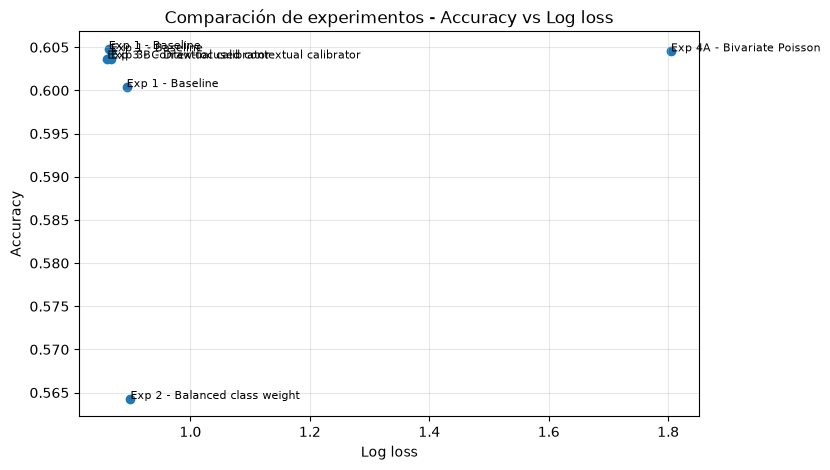

In [82]:
plt.figure(figsize=(8, 5))

plt.scatter(
    final_summary_df["log_loss"],
    final_summary_df["accuracy"],
)

for _, row in final_summary_df.iterrows():
    plt.text(
        row["log_loss"],
        row["accuracy"],
        row["experiment"],
        fontsize=8,
    )

plt.title("Comparación de experimentos - Accuracy vs Log loss")
plt.xlabel("Log loss")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.show()

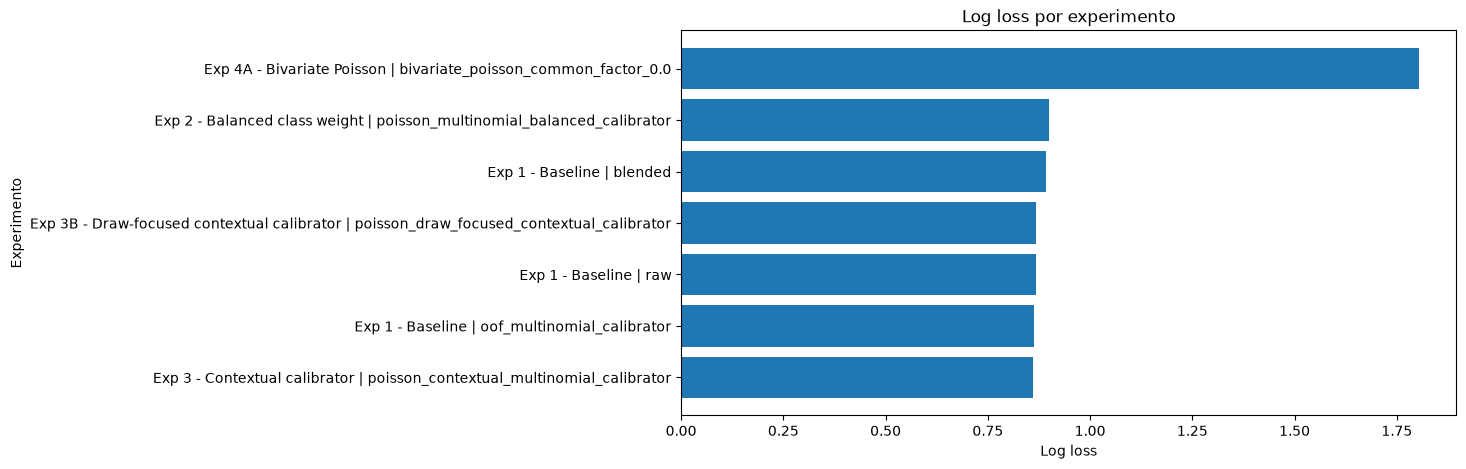

In [83]:
plot_df = final_summary_df.sort_values("log_loss", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["experiment"] + " | " + plot_df["model"], plot_df["log_loss"])

plt.title("Log loss por experimento")
plt.xlabel("Log loss")
plt.ylabel("Experimento")
plt.show()

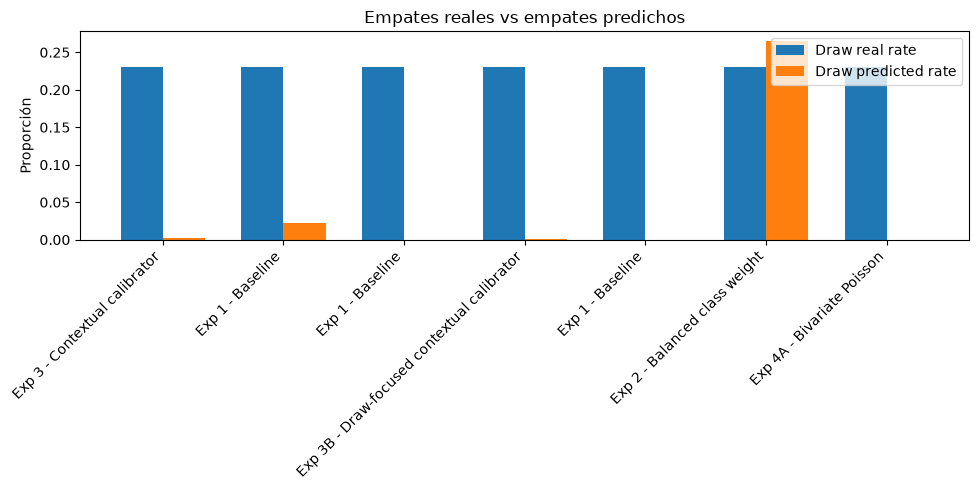

In [84]:
draw_plot_df = final_summary_df.copy()

x = np.arange(len(draw_plot_df))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    draw_plot_df["draw_real_rate"],
    width,
    label="Draw real rate",
)

plt.bar(
    x + width / 2,
    draw_plot_df["draw_pred_rate"],
    width,
    label="Draw predicted rate",
)

plt.xticks(
    x,
    draw_plot_df["experiment"],
    rotation=45,
    ha="right",
)

plt.title("Empates reales vs empates predichos")
plt.ylabel("Proporción")
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
final_summary_df.to_csv(
    "../outputs/final_experiment_summary.csv",
    index=False,
)

Se compararon distintas estrategias para mejorar la calidad probabilística del modelo, usando como métricas principales `accuracy`, `log_loss`, `draw_real_rate` y `draw_pred_rate`.

### Experimento 1 - Poisson + calibrador multinomial OOF

El modelo base con calibrador OOF multinomial mantuvo una accuracy cercana al 60% y obtuvo un log loss competitivo. Además, fue el único calibrador no forzado que logró aumentar parcialmente la predicción de empates frente al Poisson raw.

Este modelo conserva la estructura interpretable del Poisson, ya que primero estima goles esperados (`lambda_home`, `lambda_away`) y luego ajusta las probabilidades finales mediante calibración.

### Experimento 2 - Calibrador con class_weight="balanced"

El uso de `class_weight="balanced"` aumentó fuertemente el `draw_pred_rate`, pero empeoró tanto el `accuracy` como el `log_loss`.

Esto indica que el problema de los empates no se resuelve simplemente forzando el balance de clases. El modelo empezó a predecir demasiados empates, pero no de forma suficientemente precisa.

### Experimento 3 - Calibrador con features contextuales

El calibrador contextual obtuvo el mejor `log_loss` individual, pero la mejora frente al baseline calibrado fue marginal. Además, redujo casi a cero el `draw_pred_rate`.

Esto sugiere que las features contextuales ayudaron a ajustar mejor las probabilidades generales, especialmente entre victoria local y visitante, pero no resolvieron el problema estructural de los empates.

### Experimento 3B - Calibrador contextual enfocado en empates

La variante enfocada en partidos cerrados no mejoró el log loss ni logró aumentar la predicción de empates. Por lo tanto, se descarta como candidato final.

### Experimento 4 - Poisson bivariado

Se probó una extensión bivariada del modelo Poisson para capturar dependencia entre los goles de ambos equipos mediante un componente común (`common_factor`).

El tuning mostró que el menor `log_loss` se obtiene con `common_factor = 0.00`. A medida que aumenta el componente común, el `log_loss` empeora de forma sostenida.

Esto indica que, con los datos y features actuales, introducir dependencia entre los goles no mejora la calidad probabilística del modelo. Por este motivo, el experimento se descarta como candidato final.

#### Modelo final seleccionado

Aunque el calibrador contextual obtuvo el menor `log_loss`, la mejora fue muy pequeña y vino acompañada de una caída fuerte en la predicción de empates.

Por este motivo, el modelo final seleccionado es:

**Poisson + OOF Multinomial Calibrator**

Este modelo ofrece el mejor balance entre:

- accuracy competitivo;
- log loss bajo;
- interpretabilidad;
- menor riesgo de overfitting;
- mejor comportamiento relativo frente a empates que las alternativas no forzadas.

La conclusión principal es que el proyecto logró construir un modelo probabilístico sólido, donde el Poisson estima goles esperados y el calibrador mejora la calidad de las probabilidades finales.